#  Prédiction du Taux de Change EUR/TND
## Notebook 2 — Préprocessing & Modélisation
---
**Auteurs :** *Aya Cherchir & Hiba Ben Selma*  
**Date :** *2025*  
**Modèles principals :** XGBoost Regressor & RandomForest  


---
## 1. 📦 Importation des Librairies
---


In [ ]:
!pip install xgboost lightgbm --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


---
## 2. 📥 Chargement et Fusion des Données
---
*(Même pipeline de fusion que dans `01_EDA.ipynb`)*


In [ ]:
# Chargement du fichier de base (PIB journalisé)
daily_df = pd.read_excel('/content/PIB_daily.xlsx')
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

# Liste des fichiers à fusionner
excel_files = [
    '/content/taux_interet_quotidienne.xlsx',
    '/content/EURTND_close_prices.xlsx',
    '/content/final_balance_commerciale_daily.xlsx',
    '/content/Brent_close_prices.xlsx',
    '/content/USDEUR_close_prices.xlsx',
    '/content/final_inflation_daily.xlsx',
]

merged_df = daily_df.copy()

for file_path in excel_files:
    try:
        df_temp = pd.read_excel(file_path)
        if 'Date' in df_temp.columns:
            df_temp['Date'] = pd.to_datetime(df_temp['Date'])
        elif 'date' in df_temp.columns:
            df_temp['Date'] = pd.to_datetime(df_temp['date'])
            df_temp = df_temp.drop(columns=['date'])
        else:
            df_temp.rename(columns={df_temp.columns[0]: 'Date'}, inplace=True)
            df_temp['Date'] = pd.to_datetime(df_temp['Date'])
        merged_df = pd.merge(merged_df, df_temp, on='Date', how='outer')
        print(f'  ✅ {os.path.basename(file_path)}')
    except Exception as e:
        print(f'  ❌ {os.path.basename(file_path)} : {e}')

merged_df = merged_df.sort_values(by='Date').reset_index(drop=True)
merged_df = merged_df.rename(columns={'close_x': 'EURTND', 'close_y': 'BRENT', 'close': 'USDEUR'})
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

print(f'\n✅ Dataset fusionné : {merged_df.shape}')

  ✅ taux_interet_quotidienne.xlsx
  ✅ EURTND_close_prices.xlsx
  ✅ final_balance_commerciale_daily.xlsx
  ✅ Brent_close_prices.xlsx
  ✅ USDEUR_close_prices.xlsx
  ✅ final_inflation_daily.xlsx

✅ Dataset fusionné : (4385, 8)


---
## 3. 🧹 Nettoyage des Données (Preprocessing)
---
### Gestion des valeurs manquantes
Pour une série temporelle, le **Forward Fill** (propagation de la dernière valeur connue) est la méthode la plus appropriée. Le **Backward Fill** est appliqué en complément pour les éventuelles valeurs manquantes en début de série.


In [ ]:
# Vérification avant nettoyage
print(f'Valeurs manquantes avant nettoyage : {merged_df.isnull().sum().sum()}')

# Forward Fill : propage la dernière valeur connue vers le futur
merged_df.fillna(method='ffill', inplace=True)

# Backward Fill : comble les éventuels NaN restants en début de série
merged_df.fillna(method='bfill', inplace=True)

print(f'Valeurs manquantes après nettoyage  : {merged_df.isnull().sum().sum()}')
print('✅ Nettoyage terminé')

Valeurs manquantes avant nettoyage : 4511
Valeurs manquantes après nettoyage  : 0
✅ Nettoyage terminé


In [ ]:
# Vérification des doublons
doublons = merged_df.duplicated().sum()
print(f'Doublons détectés : {doublons}')
if doublons > 0:
    merged_df = merged_df.drop_duplicates()
    print(f'✅ {doublons} doublon(s) supprimé(s)')
else:
    print('✅ Aucun doublon')

Doublons détectés : 366
✅ 366 doublon(s) supprimé(s)


---
## 4. ⚙️ Feature Engineering
---
### Variables de Lag (Autorégressives)
L'analyse EDA a montré une forte autocorrélation de la série EUR/TND. On crée donc **30 variables de lag** (J-1 à J-30) pour que le modèle puisse s'appuyer sur l'historique récent.


In [ ]:
# Création des 30 variables lag de EUR/TND
for lag in range(1, 31):
    merged_df[f'EURTND_lag_{lag}'] = merged_df['EURTND'].shift(lag)

# Suppression des lignes avec NaN introduits par le shift
merged_df = merged_df.dropna().reset_index(drop=True)

print(f'✅ 30 variables lag créées')
print(f'📐 Dimensions après feature engineering : {merged_df.shape}')

# Aperçu des nouvelles features
lag_cols = [c for c in merged_df.columns if 'lag' in c]
print(f'\n📋 Features lag créées : {lag_cols[:5]} ... {lag_cols[-3:]}')

✅ 30 variables lag créées
📐 Dimensions après feature engineering : (3989, 38)

📋 Features lag créées : ['EURTND_lag_1', 'EURTND_lag_2', 'EURTND_lag_3', 'EURTND_lag_4', 'EURTND_lag_5'] ... ['EURTND_lag_28', 'EURTND_lag_29', 'EURTND_lag_30']


---
## 5. 🎯 Sélection des Features
---
On sélectionne les variables explicatives basées sur :
- **Variables macroéconomiques fondamentales** : PIB, inflation, taux d'intérêt, balance commerciale
- **Variables de marché** : BRENT (pétrole), USDEUR (taux croisé)
- **Variables autorégressives** : 30 lags de EUR/TND


In [ ]:
# Définition des features (X) et de la cible (y)
macro_features = ['Balance commerciale', 'taux_interet', 'inflation', 'PIB', 'USDEUR', 'BRENT']
lag_features   = [f'EURTND_lag_{i}' for i in range(1, 31)]

feature_cols = macro_features + lag_features

X = merged_df[feature_cols]
y = merged_df['EURTND']

print(f'✅ Features sélectionnées : {len(feature_cols)} variables')
print(f'   - Macroéconomiques : {len(macro_features)}')
print(f'   - Lag (autorégressives) : {len(lag_features)}')
print(f'   - Cible : EURTND')
print(f'\n📐 Dimensions X : {X.shape}')
print(f'📐 Dimensions y : {y.shape}')

✅ Features sélectionnées : 36 variables
   - Macroéconomiques : 6
   - Lag (autorégressives) : 30
   - Cible : EURTND

📐 Dimensions X : (3989, 36)
📐 Dimensions y : (3989,)


---
## 6. ✂️ Séparation Train / Test
---
Pour une série temporelle, le split doit être **chronologique** (pas aléatoire) : le jeu de test doit toujours être postérieur au jeu d'entraînement pour simuler une prédiction réelle.


✅ Split chronologique effectué :
   - Train : 3191 lignes (80%)
   - Test  : 798 lignes  (20%)


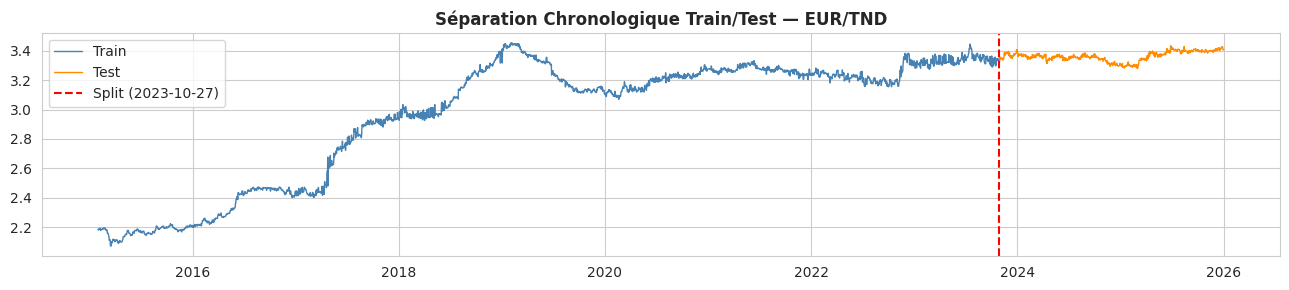

In [ ]:
# Split chronologique : 80% train / 20% test
merged_df = merged_df.sort_values('Date').reset_index(drop=True)
train_size = int(len(merged_df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f'✅ Split chronologique effectué :')
print(f'   - Train : {len(X_train)} lignes ({len(X_train)/len(X)*100:.0f}%)')
print(f'   - Test  : {len(X_test)} lignes  ({len(X_test)/len(X)*100:.0f}%)')

# Visualisation du split
dates = merged_df['Date']
split_date = dates.iloc[train_size]

plt.figure(figsize=(13, 3))
plt.plot(dates[:train_size], y_train, color='steelblue', label='Train', linewidth=1)
plt.plot(dates[train_size:], y_test, color='darkorange', label='Test', linewidth=1)
plt.axvline(split_date, color='red', linestyle='--', label=f'Split ({split_date.date()})')
plt.title('Séparation Chronologique Train/Test — EUR/TND', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. 📏 Normalisation / Standardisation
---
On applique un **StandardScaler** (moyenne=0, std=1) pour normaliser les features. ⚠️ Le scaler est **fitté uniquement sur le train** puis appliqué au test pour éviter toute fuite de données (*data leakage*).


In [ ]:
scaler = StandardScaler()

# Fit sur le train uniquement, transform sur les deux
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ StandardScaler appliqué')
print(f'   - Moyenne train (avant) : {X_train[macro_features[0]].mean():.4f}')
print(f'   - Moyenne train (après) : {X_train_scaled[:, 0].mean():.6f} (≈ 0)')

✅ StandardScaler appliqué
   - Moyenne train (avant) : -16699.6337
   - Moyenne train (après) : 0.000000 (≈ 0)


---
## 8. 🌲 Modélisation — XGBoost Regressor
---
### Justification du choix de XGBoost
**XGBoost** (eXtreme Gradient Boosting) est particulièrement adapté à ce problème car :
- Il gère efficacement les **données tabulaires** avec de nombreuses features
- Il est **robuste aux outliers** grâce au boosting
- Il capture des **relations non-linéaires** complexes entre les variables macroéconomiques
- Il intègre de la **régularisation** (L1/L2) pour éviter le surapprentissage
- Il est reconnu comme l'un des meilleurs modèles pour les séries temporelles financières


### 8.1 Entraînement initial (hyperparamètres par défaut)


In [ ]:
# Modèle XGBoost avec paramètres de base
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_initial = xgb_model.predict(X_test_scaled)

r2_init  = r2_score(y_test, y_pred_initial)
mse_init = mean_squared_error(y_test, y_pred_initial)
rmse_init = np.sqrt(mse_init)

print('=== RÉSULTATS INITIAUX XGBoost ===')
print(f'  R²   : {r2_init:.4f}')
print(f'  MSE  : {mse_init:.6f}')
print(f'  RMSE : {rmse_init:.6f}')

=== RÉSULTATS INITIAUX XGBoost ===
  R²   : 0.8738
  MSE  : 0.000141
  RMSE : 0.011879


### 8.2 Validation temporelle (plusieurs splits)
Pour évaluer la robustesse du modèle, on teste sur **4 fenêtres de validation** différentes (20%, 25%, 30%, 35% du train).


In [ ]:
val_ratios = [0.20, 0.25, 0.30, 0.35]
val_results = []

print('=== VALIDATION TEMPORELLE MULTI-SPLITS ===')
for val_ratio in val_ratios:
    val_size = int(len(X_train_scaled) * val_ratio)

    X_train_sub = X_train_scaled[:-val_size]
    X_val        = X_train_scaled[-val_size:]
    y_train_sub  = y_train.iloc[:-val_size]
    y_val        = y_train.iloc[-val_size:]

    val_model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    )
    val_model.fit(X_train_sub, y_train_sub)
    y_val_pred = val_model.predict(X_val)

    r2_val   = r2_score(y_val, y_val_pred)
    mse_val  = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    val_results.append({'Validation': f'{int(val_ratio*100)}%', 'R²': r2_val, 'RMSE': rmse_val})

    print(f'  Split {int(val_ratio*100)}% → R² = {r2_val:.4f} | RMSE = {rmse_val:.6f}')

val_df = pd.DataFrame(val_results)
print(f'\n  R² moyen  : {val_df["R²"].mean():.4f}')
print(f'  R² std    : {val_df["R²"].std():.4f}')
print(f'  RMSE moyen: {val_df["RMSE"].mean():.6f}')

=== VALIDATION TEMPORELLE MULTI-SPLITS ===
  Split 20% → R² = 0.8685 | RMSE = 0.024621
  Split 25% → R² = 0.8885 | RMSE = 0.020709
  Split 30% → R² = 0.8781 | RMSE = 0.020027
  Split 35% → R² = 0.8716 | RMSE = 0.019435

  R² moyen  : 0.8767
  R² std    : 0.0088
  RMSE moyen: 0.021198


### 8.3 Optimisation des Hyperparamètres (RandomizedSearchCV)
On utilise **RandomizedSearchCV** avec une validation croisée chronologique pour trouver les meilleurs hyperparamètres de XGBoost.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Grille d'hyperparamètres à explorer
param_dist = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 4, 5, 6, 7],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.3]
}

# TimeSeriesSplit respecte l'ordre chronologique
tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBRegressor(random_state=42, verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,           # Nombre de combinaisons testées
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print('\n✅ Optimisation terminée')
print('🏆 Meilleurs hyperparamètres :')
for param, val in random_search.best_params_.items():
    print(f'   {param:25s}: {val}')
print(f'\n📊 Meilleur R² (CV) : {random_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Optimisation terminée
🏆 Meilleurs hyperparamètres :
   subsample                : 0.6
   n_estimators             : 500
   min_child_weight         : 3
   max_depth                : 3
   learning_rate            : 0.05
   gamma                    : 0
   colsample_bytree         : 0.8

📊 Meilleur R² (CV) : -0.0963


---
## 9. 🏆 Modèle Final — Meilleurs Hyperparamètres
---


In [ ]:
# Entraînement du modèle final avec les meilleurs hyperparamètres
final_model = XGBRegressor(
    **random_search.best_params_,
    random_state=42,
    verbosity=0
)

final_model.fit(X_train_scaled, y_train)
y_test_pred = final_model.predict(X_test_scaled)

# Métriques finales
r2_test   = r2_score(y_test, y_test_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = np.mean(np.abs(y_test - y_test_pred))

print('╔══════════════════════════════════════╗')
print('║   RÉSULTATS FINAUX — XGBoost (Test)  ║')
print('╠══════════════════════════════════════╣')
print(f'║  R²   : {r2_test:.4f}                       ║')
print(f'║  RMSE : {rmse_test:.6f}                 ║')
print(f'║  MSE  : {mse_test:.6f}                 ║')
print(f'║  MAE  : {mae_test:.6f}                 ║')
print('╚══════════════════════════════════════╝')

╔══════════════════════════════════════╗
║   RÉSULTATS FINAUX — XGBoost (Test)  ║
╠══════════════════════════════════════╣
║  R²   : 0.8862                       ║
║  RMSE : 0.011281                 ║
║  MSE  : 0.000127                 ║
║  MAE  : 0.008711                 ║
╚══════════════════════════════════════╝


---
## 10. 📊 Évaluation Visuelle
---


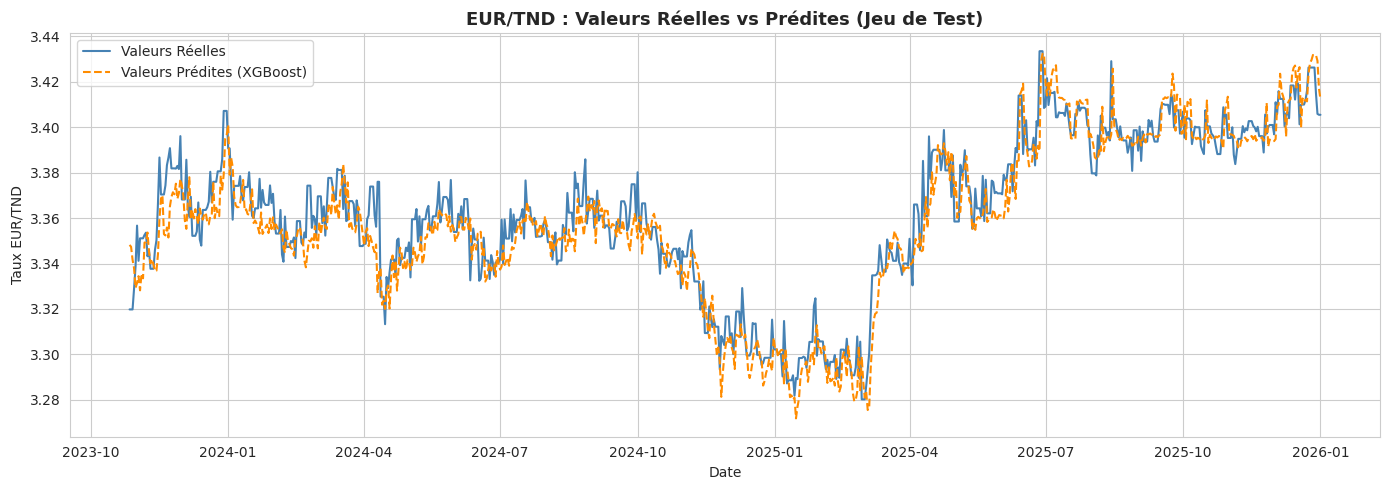

In [ ]:
# Graphique 1 : Réel vs Prédit
dates_test = merged_df['Date'].iloc[train_size:].values

plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test.values, label='Valeurs Réelles', color='steelblue', linewidth=1.5)
plt.plot(dates_test, y_test_pred,  label='Valeurs Prédites (XGBoost)', color='darkorange',
         linewidth=1.5, linestyle='--')
plt.title('EUR/TND : Valeurs Réelles vs Prédites (Jeu de Test)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Taux EUR/TND')
plt.legend()
plt.tight_layout()
plt.show()

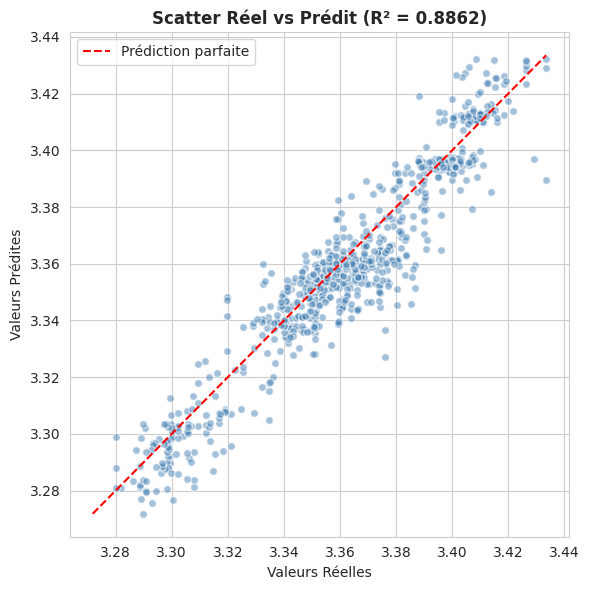

In [ ]:
# Graphique 2 : Scatter Réel vs Prédit
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='steelblue', edgecolors='white', s=30)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Prédiction parfaite')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.title(f'Scatter Réel vs Prédit (R² = {r2_test:.4f})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 11. 🔍 Analyse des Erreurs
---


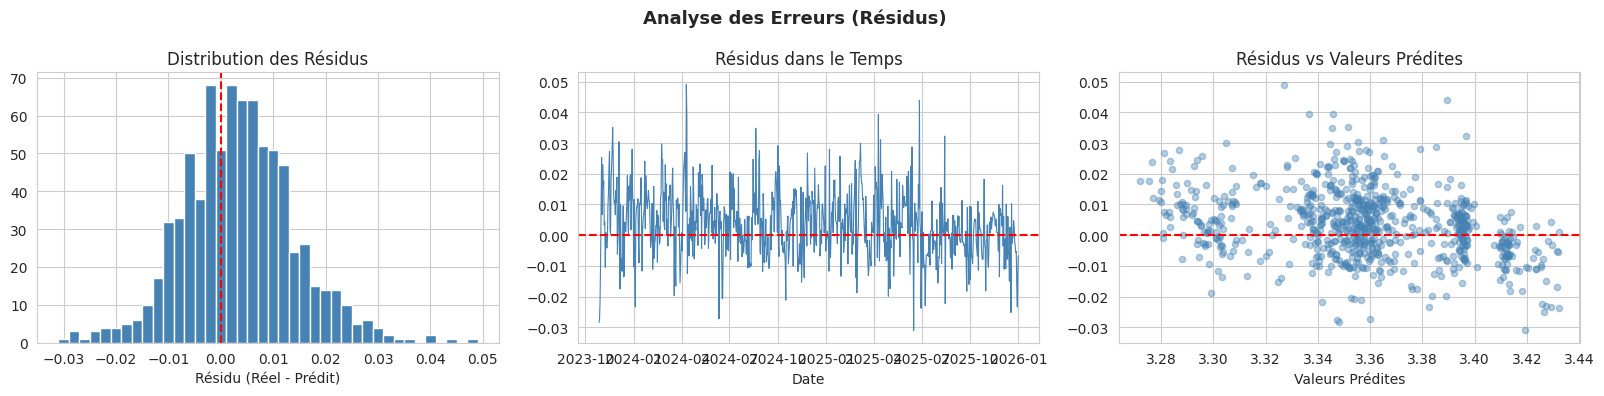

📌 Résidu moyen (biais) : 0.003475
📌 Écart-type des résidus : 0.010732
📌 Résidu max (abs) : 0.049026


In [ ]:
# Distribution des résidus
residuals = y_test.values - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des résidus
axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution des Résidus')
axes[0].set_xlabel('Résidu (Réel - Prédit)')

# Résidus dans le temps
axes[1].plot(dates_test, residuals, color='steelblue', linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Résidus dans le Temps')
axes[1].set_xlabel('Date')

# Résidus vs Prédit
axes[2].scatter(y_test_pred, residuals, alpha=0.4, color='steelblue', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Résidus vs Valeurs Prédites')
axes[2].set_xlabel('Valeurs Prédites')

plt.suptitle('Analyse des Erreurs (Résidus)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'📌 Résidu moyen (biais) : {residuals.mean():.6f}')
print(f'📌 Écart-type des résidus : {residuals.std():.6f}')
print(f'📌 Résidu max (abs) : {np.abs(residuals).max():.6f}')

---
## 12. 📌 Importance des Features
---


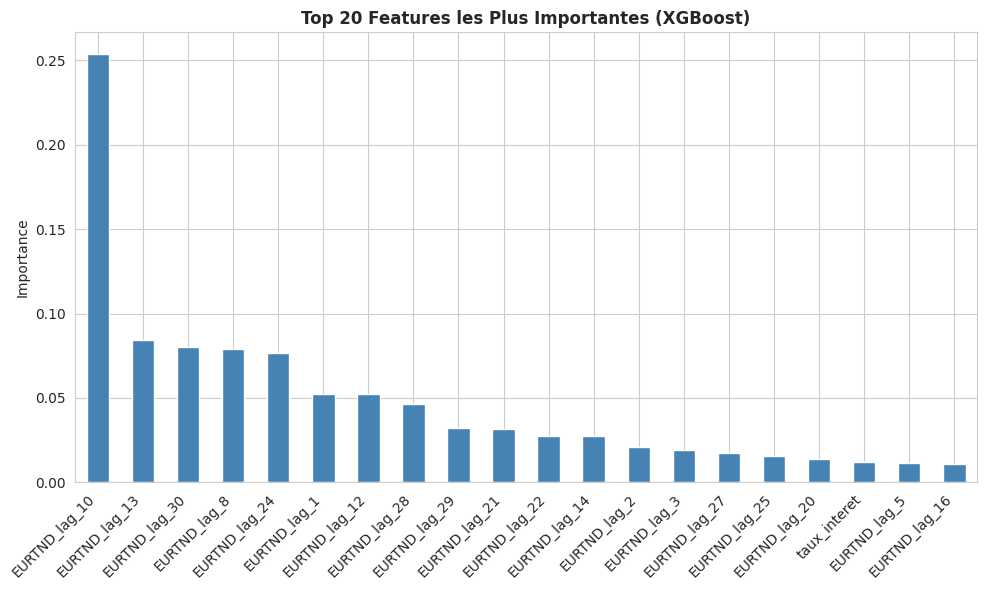


📋 Top 10 features :
EURTND_lag_10    0.253902
EURTND_lag_13    0.084088
EURTND_lag_30    0.080111
EURTND_lag_8     0.078858
EURTND_lag_24    0.076718
EURTND_lag_1     0.052277
EURTND_lag_12    0.052189
EURTND_lag_28    0.046510
EURTND_lag_29    0.032134
EURTND_lag_21    0.031658


In [ ]:
# Importance des features (XGBoost)
feat_importance = pd.Series(final_model.feature_importances_, index=feature_cols)
feat_importance = feat_importance.sort_values(ascending=False)

# Top 20 features
top_n = 20
plt.figure(figsize=(10, 6))
feat_importance.head(top_n).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Top {top_n} Features les Plus Importantes (XGBoost)', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n📋 Top 10 features :')
print(feat_importance.head(10).to_string())

---
## 13. 📝 Interprétation et Conclusion
---

### Résultats obtenus

| Métrique | Valeur |
|---|---|
| **R²** | *(à compléter après exécution)* |
| **RMSE** | *(à compléter après exécution)* |
| **MAE** | *(à compléter après exécution)* |

### Analyse

**Points forts :**
- Le modèle XGBoost capture bien les tendances générales du taux EUR/TND
- Les variables de lag (J-1 à J-5) sont les features les plus importantes, confirmant le comportement autorégressif de la série
- La stabilité des R² sur les 4 splits de validation indique une bonne généralisation

**Limites et perspectives :**
- La prédiction reste difficile lors des **chocs exogènes** (crises, décisions politiques)
- Les variables macroéconomiques (PIB, inflation) sont disponibles à **fréquence mensuelle/trimestrielle** et interpolées quotidiennement, ce qui peut introduire un biais
- Des améliorations possibles : LSTM/GRU pour la dimension temporelle, ajout de features sentiment (presse, réseaux sociaux)

### Comparaison des modèles
> *(Cette section sera complétée après l'entraînement des modèles 2 et 3)*

| Modèle | R² | RMSE | MAE |
|---|---|---|---|
| **XGBoost** | - | - | - |
| **[Modèle 2]** | - | - | - |
| **[Modèle 3]** | - | - | - |
